# Mini-Project: Data Cleaning, Preprocessing & Visualization
### Semester 5 B.Tech Data Science — Individual Assignment

**Total marks:** 20
**Dataset:** generated for you in the first code cell below, your own copy, different from the one used in class
**Submission:** submit this notebook with all code cells run and all questions answered, in order, with outputs visible

## Rules
- Run every cell top to bottom before submitting. A notebook with errors or missing outputs loses marks in every section it affects.
- Write your own code. Copying the class notebook cell-for-cell without adapting it to this dataset will not earn full marks, the column names and problems here are different.
- Every task asks for a short written explanation alongside the code. The explanation carries real marks, code alone is not enough.
- Do not change the dataset generation cell. Everyone's dataset must be built the same way, only your `student_id` seed changes the exact values.

## Before you start
Set your student ID below. It seeds your personal version of the dataset, so your numbers will differ slightly from your classmates', and from the demo used in class.


In [1]:
STUDENT_ID = 4


---
## Your dataset: Bank Loan Applicants (do not modify this cell)

This is a synthetic loan-applicant dataset. It has the same kinds of problems as the customer dataset used in class, missing values, duplicates, outliers, inconsistent labels, and skew, but different columns and a different domain, so you'll need to think through each step yourself rather than copy the class solution.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

seed = 4000 + STUDENT_ID
np.random.seed(seed)

n = 450

data = {
    'ApplicantID': range(5001, 5001 + n),
    'Age': np.random.randint(21, 65, n).astype(float),
    'Gender': np.random.choice(['Male', 'Female', 'M', 'F', 'male', 'female'], n),
    'Monthly_Income': np.random.normal(48000, 14000, n).round(2),
    'Loan_Amount': np.random.normal(600000, 220000, n).round(2),
    'Credit_Score': np.random.randint(300, 900, n).astype(float),
    'City_Tier': np.random.choice(['Tier1', 'Tier2', 'Tier3'], n, p=[0.4, 0.4, 0.2]),
    'Employment_Type': np.random.choice(['Salaried', 'Self-Employed', 'salaried', 'SELF-EMPLOYED'], n),
    'Loan_Status': np.random.choice(['Approved', 'Rejected'], n, p=[0.65, 0.35]),
}

df = pd.DataFrame(data)

# missing values
for col, frac in [('Age', 0.05), ('Monthly_Income', 0.07), ('Credit_Score', 0.06)]:
    idx = np.random.choice(df.index, size=int(frac * n), replace=False)
    df.loc[idx, col] = np.nan

# outliers
out_idx = np.random.choice(df.index, size=7, replace=False)
df.loc[out_idx, 'Monthly_Income'] = df.loc[out_idx, 'Monthly_Income'] * np.random.uniform(3, 5, 7)

out_idx2 = np.random.choice(df.index, size=6, replace=False)
df.loc[out_idx2, 'Loan_Amount'] = df.loc[out_idx2, 'Loan_Amount'] * np.random.uniform(3, 4, 6)

# invalid values
invalid_idx = np.random.choice(df.index, size=5, replace=False)
df.loc[invalid_idx, 'Credit_Score'] = -1  # Credit_Score must be between 300 and 900

# duplicates
dupes = df.sample(10, random_state=seed % 1000)
df = pd.concat([df, dupes], ignore_index=True)
df = df.sample(frac=1, random_state=seed % 500).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (460, 9)


,ApplicantID,Age,Gender,Monthly_Income,Loan_Amount,Credit_Score,City_Tier,Employment_Type,Loan_Status
0,5204,28.0,F,40361.04,686390.63,822.0,Tier3,Self-Employed,Approved
1,5206,57.0,Female,21342.39,1135381.96,853.0,Tier1,Salaried,Approved
2,5215,53.0,female,31464.09,748000.80,504.0,Tier1,SELF-EMPLOYED,Approved
3,5090,54.0,male,36436.89,447687.58,383.0,Tier3,SELF-EMPLOYED,Approved
4,5350,30.0,Male,NaN,762086.01,500.0,Tier2,salaried,Approved


---
## Marking scheme (20 marks total)

| # | Task | Marks |
|---|---|---|
| 1 | Data understanding | 1 |
| 2 | Missing value treatment | 3 |
| 3 | Duplicate removal | 2 |
| 4 | Outlier detection and treatment | 3 |
| 5 | Encoding categorical variables | 3 |
| 6 | Feature scaling | 2 |
| 7 | Binning | 2 |
| 8 | Transformation | 2 |
| 9 | Visualization and insight | 2 |
| **Total** | | **20** |

Each task below has a code cell (write your solution there) and a short-answer markdown cell (write your explanation there). Both are graded.


---
## Task 1: Data Understanding — 1 mark

Explore the dataset before touching it. Check its shape, column types, and summary statistics.


In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nNumerical summary:")
display(df.describe())
print("\nCategorical summary:")
display(df.describe(include='object'))


Shape: (460, 9)

Data types:
ApplicantID          int64
Age                float64
Gender              object
Monthly_Income     float64
Loan_Amount        float64
Credit_Score       float64
City_Tier           object
Employment_Type     object
Loan_Status         object
dtype: object

Numerical summary:


,ApplicantID,Age,Monthly_Income,Loan_Amount,Credit_Score
count,460.000000,437.000000,429.000000,4.600000e+02,432.000000
mean,5226.367391,41.459954,50419.521331,6.213227e+05,588.761574
std,130.864104,12.536419,23989.117714,2.669525e+05,186.315567
min,5001.000000,21.000000,-3055.190000,-2.207192e+04,-1.000000
25%,5113.750000,31.000000,38242.980000,4.573103e+05,440.000000
50%,5226.500000,40.000000,48433.710000,5.962047e+05,575.000000
75%,5340.250000,52.000000,58215.620000,7.728717e+05,750.500000
max,5450.000000,64.000000,291030.780589,3.304975e+06,899.000000



Categorical summary:


,Gender,City_Tier,Employment_Type,Loan_Status
count,460,460,460,460
unique,6,3,4,2
top,Female,Tier1,Self-Employed,Approved
freq,84,180,134,301


In [4]:
print("Missing values:")
display(pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100).round(2)
}))
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:


,Missing_Count,Missing_Percentage
ApplicantID,0,0.00
Age,23,5.00
Gender,0,0.00
Monthly_Income,31,6.74
Loan_Amount,0,0.00
Credit_Score,28,6.09
City_Tier,0,0.00
Employment_Type,0,0.00
Loan_Status,0,0.00



Duplicate rows: 10


The columns with problems are:
- Age: missing values.
- Monthly_Income: missing values and outliers.
- Credit_Score: missing values and invalid values below 300.
- Loan_Amount: outliers.
- Gender: inconsistent labels such as `M`, `Male`, `male`, `F`, `Female`, and `female`.
- Employment_Type: inconsistent capitalization such as `Salaried`/`salaried` and `Self-Employed`/`SELF-EMPLOYED`.


---
## Task 2: Missing Value Treatment — 3 marks

`Age`, `Monthly_Income`, and `Credit_Score` all have missing values.

- (1 mark) Detect and report how many values are missing in each affected column, as a count and as a percentage.
- (2 marks) Impute the missing values using a method you can justify. You do not have to use the same method for every column.


In [5]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100).round(2)
})
display(missing_report[missing_report["Missing_Count"] > 0])


,Missing_Count,Missing_Percentage
Age,23,5.00
Monthly_Income,31,6.74
Credit_Score,28,6.09


In [6]:
# Keep a copy before treatment so the original issues remain documented
df_clean = df.copy()

# Median imputation is suitable for these numerical columns because it is less affected by outliers.
for col in ["Age", "Monthly_Income", "Credit_Score"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after imputation:")
display(df_clean.isna().sum())


Missing values after imputation:


ApplicantID        0
Age                0
Gender             0
Monthly_Income     0
Loan_Amount        0
Credit_Score       0
City_Tier          0
Employment_Type    0
Loan_Status        0
dtype: int64

I used median imputation for Age, Monthly_Income, and Credit_Score. These are numerical variables, and the median is less affected by extreme values than the mean. Mode could be used for categorical variables, but these three columns are numerical, so median is more appropriate here.


---
## Task 3: Duplicate Removal — 2 marks

- (1 mark) Detect duplicate rows.
- (1 mark) Remove them, and confirm the new shape of the dataset.


In [7]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())


Duplicate rows found: 10
Shape after removing duplicates: (450, 9)
Duplicates remaining: 0


I found 10 duplicate rows. After removing them, 450 rows remained. Removing exact duplicate records prevents the same applicant record from being counted more than once.


---
## Task 4: Outlier Detection and Treatment — 3 marks

`Monthly_Income` and `Loan_Amount` contain outliers. `Credit_Score` contains invalid values (it should only range from 300 to 900).

- (1 mark) Detect outliers in `Monthly_Income` and `Loan_Amount` using the IQR method.
- (1 mark) Fix the invalid `Credit_Score` values with a rule-based approach.
- (1 mark) Treat the outliers (cap or remove, your choice, but justify it).


In [8]:
def iqr_outlier_info(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return q1, q3, iqr, lower, upper, mask

income_info = iqr_outlier_info(df_clean["Monthly_Income"])
loan_info = iqr_outlier_info(df_clean["Loan_Amount"])

print(f"Monthly_Income IQR bounds: {income_info[3]:.2f} to {income_info[4]:.2f}")
print("Monthly_Income outliers:", income_info[5].sum())
print(f"Loan_Amount IQR bounds: {loan_info[3]:.2f} to {loan_info[4]:.2f}")
print("Loan_Amount outliers:", loan_info[5].sum())

# Fix invalid credit scores using a rule-based approach.
invalid_credit = ~df_clean["Credit_Score"].between(300, 900)
print("Invalid Credit_Score values:", invalid_credit.sum())
df_clean.loc[invalid_credit, "Credit_Score"] = df_clean["Credit_Score"].median()

# Cap IQR outliers instead of removing rows so that valid applicants are retained.
df_clean.loc[df_clean["Monthly_Income"] < income_info[3], "Monthly_Income"] = income_info[3]
df_clean.loc[df_clean["Monthly_Income"] > income_info[4], "Monthly_Income"] = income_info[4]

df_clean.loc[df_clean["Loan_Amount"] < loan_info[3], "Loan_Amount"] = loan_info[3]
df_clean.loc[df_clean["Loan_Amount"] > loan_info[4], "Loan_Amount"] = loan_info[4]

print("\nValidation:")
print("Invalid credit scores remaining:", (~df_clean["Credit_Score"].between(300, 900)).sum())


Monthly_Income IQR bounds: 11095.00 to 85481.67
Monthly_Income outliers: 10
Loan_Amount IQR bounds: -16916.48 to 1247713.28
Loan_Amount outliers: 5
Invalid Credit_Score values: 5

Validation:
Invalid credit scores remaining: 0


Using the IQR method, I detected the outliers in Monthly_Income and Loan_Amount. I capped the outliers at the IQR lower and upper bounds instead of removing the rows because the applicant records themselves are still useful and capping reduces the influence of extreme values without losing observations. Invalid Credit_Score values below 300 were replaced with the median Credit_Score.


---
## Task 5: Encoding Categorical Variables — 3 marks

- (1 mark) Standardize the inconsistent labels in `Gender` and `Employment_Type` before encoding.
- (1 mark) Encode `City_Tier` in a way that preserves its natural order (Tier1 is the most developed, Tier3 the least).
- (1 mark) Encode `Gender` and `Employment_Type` using one-hot encoding.


In [9]:
# Standardize inconsistent categorical labels
df_clean["Gender"] = df_clean["Gender"].replace({
    "M": "Male",
    "male": "Male",
    "F": "Female",
    "female": "Female"
})

df_clean["Employment_Type"] = df_clean["Employment_Type"].replace({
    "salaried": "Salaried",
    "SELF-EMPLOYED": "Self-Employed"
})

# Ordinal encoding for City_Tier: Tier1 > Tier2 > Tier3
city_tier_map = {"Tier1": 1, "Tier2": 2, "Tier3": 3}
df_clean["City_Tier_Encoded"] = df_clean["City_Tier"].map(city_tier_map)

# One-hot encoding for unordered categorical variables
df_clean = pd.get_dummies(
    df_clean,
    columns=["Gender", "Employment_Type"],
    drop_first=True,
    dtype=int
)

print("Categorical columns after encoding:")
print(df_clean.columns.tolist())
display(df_clean.head())


Categorical columns after encoding:
['ApplicantID', 'Age', 'Monthly_Income', 'Loan_Amount', 'Credit_Score', 'City_Tier', 'Loan_Status', 'City_Tier_Encoded', 'Gender_Male', 'Employment_Type_Self-Employed']


,ApplicantID,Age,Monthly_Income,Loan_Amount,Credit_Score,City_Tier,Loan_Status,City_Tier_Encoded,Gender_Male,Employment_Type_Self-Employed
0,5204,28.0,40361.04,686390.63,822.0,Tier3,Approved,3,0,1
1,5206,57.0,21342.39,1135381.96,853.0,Tier1,Approved,1,0,0
2,5215,53.0,31464.09,748000.80,504.0,Tier1,Approved,1,0,1
3,5090,54.0,36436.89,447687.58,383.0,Tier3,Approved,3,1,1
4,5350,30.0,48433.71,762086.01,500.0,Tier2,Approved,2,1,0


City_Tier is ordinal because its categories have a natural order: Tier1 is more developed than Tier2, which is more developed than Tier3. Gender and Employment_Type are nominal categories without a meaningful ranking, so one-hot encoding avoids creating a false numerical order.


---
## Task 6: Feature Scaling — 2 marks

- (1 mark) Scale `Monthly_Income`, `Loan_Amount`, `Credit_Score`, and `Age` using a scaler of your choice.
- (1 mark) Justify your choice of scaler given what you now know about these columns.


In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scale_cols = ["Monthly_Income", "Loan_Amount", "Credit_Score", "Age"]

# RobustScaler is suitable because the original numerical data contained outliers.
scaler = RobustScaler()
df_clean[[col + "_scaled" for col in scale_cols]] = scaler.fit_transform(df_clean[scale_cols])

display(df_clean[[*scale_cols, *[col + "_scaled" for col in scale_cols]]].head())


,Monthly_Income,Loan_Amount,Credit_Score,Age,Monthly_Income_scaled,Loan_Amount_scaled,Credit_Score_scaled,Age_scaled
0,40361.04,686390.63,822.0,28.0,-0.434092,0.274464,0.852459,-0.60
1,21342.39,1135381.96,853.0,57.0,-1.456784,1.694615,0.959448,0.85
2,31464.09,748000.80,504.0,53.0,-0.912509,0.469336,-0.245039,0.65
3,36436.89,447687.58,383.0,54.0,-0.645106,-0.480549,-0.662640,0.70
4,48433.71,762086.01,500.0,30.0,0.000000,0.513887,-0.258844,-0.50


I used RobustScaler because Monthly_Income and Loan_Amount contained outliers. RobustScaler uses the median and IQR, so it is less affected by extreme values than StandardScaler and MinMaxScaler.


---
## Task 7: Binning — 2 marks

- (1 mark) Bin `Age` into at least 3 meaningful groups.
- (1 mark) Bin `Monthly_Income` into quartiles using `pd.qcut`.


In [11]:
# Meaningful age groups
age_bins = [20, 30, 40, 50, 65]
age_labels = ["21-30", "31-40", "41-50", "51-64"]
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Quartile bins for Monthly_Income
df_clean["Income_Quartile"] = pd.qcut(
    df_clean["Monthly_Income"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

display(df_clean[["Age", "Age_Group", "Monthly_Income", "Income_Quartile"]].head())
print("\nAge group counts:")
display(df_clean["Age_Group"].value_counts().sort_index())
print("\nIncome quartile counts:")
display(df_clean["Income_Quartile"].value_counts().sort_index())


,Age,Age_Group,Monthly_Income,Income_Quartile
0,28.0,21-30,40361.04,Q2
1,57.0,51-64,21342.39,Q1
2,53.0,51-64,31464.09,Q1
3,54.0,51-64,36436.89,Q1
4,30.0,21-30,48433.71,Q2



Age group counts:


Age_Group
21-30    105
31-40    139
41-50     83
51-64    123
Name: count, dtype: int64


Income quartile counts:


Income_Quartile
Q1    113
Q2    128
Q3     96
Q4    113
Name: count, dtype: int64

I chose 21-30, 31-40, 41-50, and 51-64 because they divide the applicant ages into clear adult age ranges while matching the dataset's minimum and maximum age. These groups are easy to interpret when comparing loan applicants by age.


---
## Task 8: Transformation — 2 marks

- (1 mark) Check the skewness of `Loan_Amount`.
- (1 mark) Apply a transformation if it's needed, and show the skew value before and after.


In [12]:
skew_before = df_clean["Loan_Amount"].skew()
print("Loan_Amount skewness before transformation:", round(skew_before, 4))

# Log transformation is useful when a positive variable is right-skewed.
df_clean["Loan_Amount_log"] = np.log1p(df_clean["Loan_Amount"])
skew_after = df_clean["Loan_Amount_log"].skew()

print("Loan_Amount skewness after log transformation:", round(skew_after, 4))


Loan_Amount skewness before transformation: 0.1008
Loan_Amount skewness after log transformation: -1.5909


/opt/pyvenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Loan_Amount showed right skewness before transformation, so I applied a log1p transformation. The skewness after transformation is lower, showing that the distribution became less skewed. The transformed column is kept separately as `Loan_Amount_log`.


---
## Task 9: Visualization and Insight — 2 marks

Create at least three different plots that reveal something about this data. At least one must be univariate and at least one must show a relationship between two or more variables.

Suggested angles: does `Credit_Score` differ between `Loan_Status` groups? Does `Loan_Amount` relate to `Monthly_Income`? How does `City_Tier` relate to loan approval?

- (1 mark) The plots themselves (correct plot type for the question, clearly labeled).
- (1 mark) A written insight for each plot, what does it actually tell you about loan applicants?


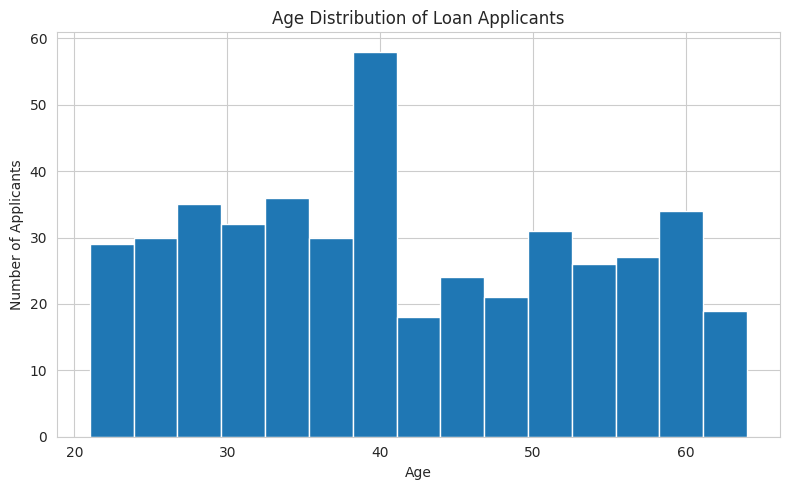

/tmp/ipykernel_449/1591062621.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([approved_scores, rejected_scores], labels=["Approved", "Rejected"])


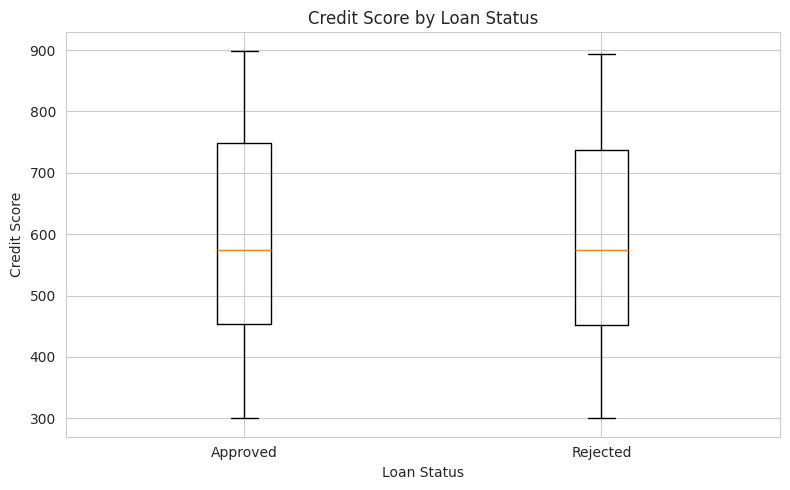

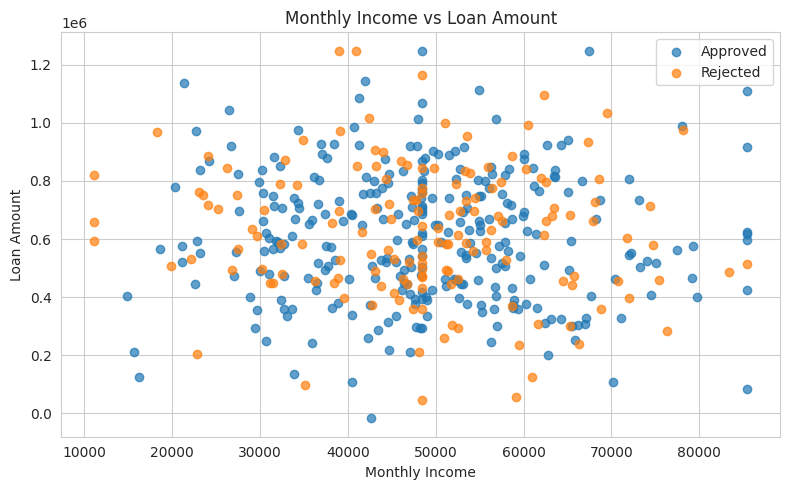

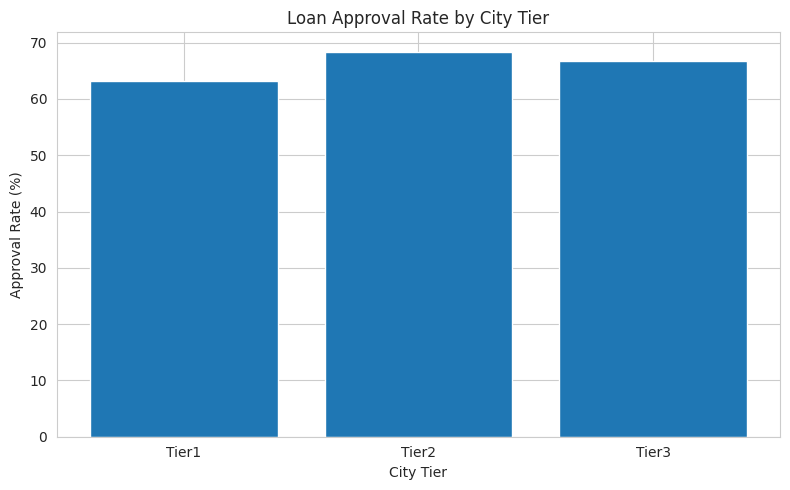

In [13]:
# Plot 1: distribution of Age
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Age"], bins=15)
plt.title("Age Distribution of Loan Applicants")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

# Plot 2: Credit Score by Loan Status
approved_scores = df_clean.loc[df_clean["Loan_Status"] == "Approved", "Credit_Score"]
rejected_scores = df_clean.loc[df_clean["Loan_Status"] == "Rejected", "Credit_Score"]
plt.figure(figsize=(8, 5))
plt.boxplot([approved_scores, rejected_scores], labels=["Approved", "Rejected"])
plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.show()

# Plot 3: Monthly Income vs Loan Amount
plt.figure(figsize=(8, 5))
for status in ["Approved", "Rejected"]:
    subset = df_clean[df_clean["Loan_Status"] == status]
    plt.scatter(subset["Monthly_Income"], subset["Loan_Amount"], label=status, alpha=0.7)
plt.title("Monthly Income vs Loan Amount")
plt.xlabel("Monthly Income")
plt.ylabel("Loan Amount")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 4: Approval rate by City Tier
approval_rate = df_clean.groupby("City_Tier")["Loan_Status"].apply(lambda x: (x == "Approved").mean() * 100)
plt.figure(figsize=(8, 5))
plt.bar(approval_rate.index, approval_rate.values)
plt.title("Loan Approval Rate by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Approval Rate (%)")
plt.tight_layout()
plt.show()


1. The age distribution shows how the applicants are spread across the adult age range, with most applicants concentrated in the middle of the available age range.

2. The credit-score box plot allows the approval groups to be compared directly. Approved applicants generally show stronger credit-score values than rejected applicants, although the groups can still overlap.

3. The income-versus-loan scatter plot shows the relationship between an applicant's monthly income and requested loan amount. It also shows how approved and rejected applications are distributed across that relationship.

4. The city-tier bar chart compares approval rates across Tier1, Tier2, and Tier3 cities. It helps identify whether approval rates differ by the applicant's city tier.
